# GR00T Inference

This tutorial shows how to use the GR00T inference model to predict the actions from the observations, given a test dataset.

In [1]:
import os
import torch
import gr00t

from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.model.policy import Gr00tPolicy

/home/korea_bupj/rilab/kdy/miniconda3/envs/gr00t/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/korea_bupj/rilab/kdy/miniconda3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2026-05-06 22:43:22.239724: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 22:43:22.264801: E external/local_xla/xla/stream_execut

In [2]:
# change the following paths
MODEL_PATH = "/home/korea_bupj/rilab/kdy/Isaac-GR00T/checkpoint-52000"
DATASET_PATH = "/home/korea_bupj/rilab/kdy/Isaac-GR00T/demo_data/merge_ffw_sh5_rev1_20260504_27dof_pick_up_a_red_cylinder_and_place_it_on_the_basket"
DATA_CONFIG_NAME = "ffw_sh5_27dof"

# If your fine-tuning used a custom tag, set that tag.
# For this dataset, new_embodiment is commonly used.
EMBODIMENT_TAG = "new_embodiment"

device = "cuda" if torch.cuda.is_available() else "cpu"

## Loading Pretrained Policy

Policy Model is loaded just like any other huggingface model.

There are 2 new concepts here in the GR00T model:
 - modality config: This defines the keys in the dictionary used by the model. (e.g. `action`, `state`, `annotation`, `video`)
 - modality_transform: A sequence of transform which are used during dataloading

In [3]:
from gr00t.experiment.data_config import load_data_config


data_config = load_data_config(DATA_CONFIG_NAME)
modality_config = data_config.modality_config()
modality_transform = data_config.transform()

policy = Gr00tPolicy(
    model_path=MODEL_PATH,
    embodiment_tag=EMBODIMENT_TAG,
    modality_config=modality_config,
    modality_transform=modality_transform,
    device=device,
)

# print out the policy model architecture
print(policy.model)

`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Model not found or avail in the huggingface hub. Loading from local path: /home/korea_bupj/rilab/kdy/Isaac-GR00T/checkpoint-52000
Loading pretrained dual brain from /home/korea_bupj/rilab/kdy/Isaac-GR00T/checkpoint-52000
Tune backbone vision tower: True
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True
Model not found or avail in the huggingface hub. Loading from local path: /home/korea_bupj/rilab/kdy/Isaac-GR00T/checkpoint-52000
Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.55s/it]


Tune backbone llm: False
Tune backbone visual: True
Tune action head projector: True
Tune action head diffusion model: True
GR00T_N1_5(
  (backbone): EagleBackbone(
    (eagle_model): Eagle2_5_VLForConditionalGeneration(
      (vision_model): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(256, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_f

In [4]:
data_config

FfwSh5Rev127DofDataConfig()

In [5]:
modality_config

{'video': ModalityConfig(delta_indices=[0], modality_keys=['video.cam_head']),
 'state': ModalityConfig(delta_indices=[0], modality_keys=['state.right_arm', 'state.right_hand']),
 'action': ModalityConfig(delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], modality_keys=['action.right_arm', 'action.right_hand']),
 'language': ModalityConfig(delta_indices=[0], modality_keys=['annotation.human.task_description'])}

## Loading dataset

First this requires user to check which embodiment tags are used to pretrained the `Gr00tPolicy` pretrained models.

In [6]:
import numpy as np

modality_config = policy.modality_config

print(modality_config.keys())

for key, value in modality_config.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


dict_keys(['video', 'state', 'action', 'language'])
video delta_indices=[0] modality_keys=['video.cam_head']
state delta_indices=[0] modality_keys=['state.right_arm', 'state.right_hand']
action delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] modality_keys=['action.right_arm', 'action.right_hand']
language delta_indices=[0] modality_keys=['annotation.human.task_description']


In [7]:
# Create the dataset
dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_config,
    video_backend="decord",
    video_backend_kwargs=None,
    transforms=None,  # We'll handle transforms separately through the policy
    embodiment_tag=EMBODIMENT_TAG,
)

Initialized dataset merge_ffw_sh5_rev1_20260504_27dof_pick_up_a_red_cylinder_and_place_it_on_the_basket with new_embodiment


In [8]:
dataset.modality_configs

{'video': ModalityConfig(delta_indices=[0], modality_keys=['video.cam_head']),
 'state': ModalityConfig(delta_indices=[0], modality_keys=['state.right_arm', 'state.right_hand']),
 'action': ModalityConfig(delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], modality_keys=['action.right_arm', 'action.right_hand']),
 'language': ModalityConfig(delta_indices=[0], modality_keys=['annotation.human.task_description'])}

Let's print out a single data and visualize it

In [9]:
import numpy as np

step_data = dataset[0]
step_data2 = dataset[200]

print(step_data)

print("\n\n ====================================")
for key, value in step_data.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


{'video.cam_head': array([[[[ 62,  67,  75],
         [ 62,  67,  75],
         [ 62,  67,  75],
         ...,
         [ 52,  51,  54],
         [ 52,  51,  54],
         [ 52,  51,  54]],

        [[ 62,  67,  75],
         [ 62,  67,  75],
         [ 62,  67,  75],
         ...,
         [ 52,  51,  54],
         [ 52,  51,  54],
         [ 52,  51,  54]],

        [[ 62,  67,  75],
         [ 62,  67,  75],
         [ 62,  67,  75],
         ...,
         [ 52,  51,  54],
         [ 52,  51,  54],
         [ 52,  51,  54]],

        ...,

        [[ 67,  67,  67],
         [ 67,  67,  67],
         [ 67,  67,  67],
         ...,
         [232, 234, 234],
         [232, 234, 234],
         [232, 234, 234]],

        [[ 67,  67,  67],
         [ 67,  67,  67],
         [ 67,  67,  67],
         ...,
         [232, 234, 234],
         [232, 234, 234],
         [232, 234, 234]],

        [[ 67,  67,  67],
         [ 67,  67,  67],
         [ 67,  67,  67],
         ...,
         [232, 

Let's plot just the "right hand" state and action data and see how it looks like. Also show the images of the right hand state.

Using keys -> state: state.right_arm, action: action.right_arm, video: video.cam_head


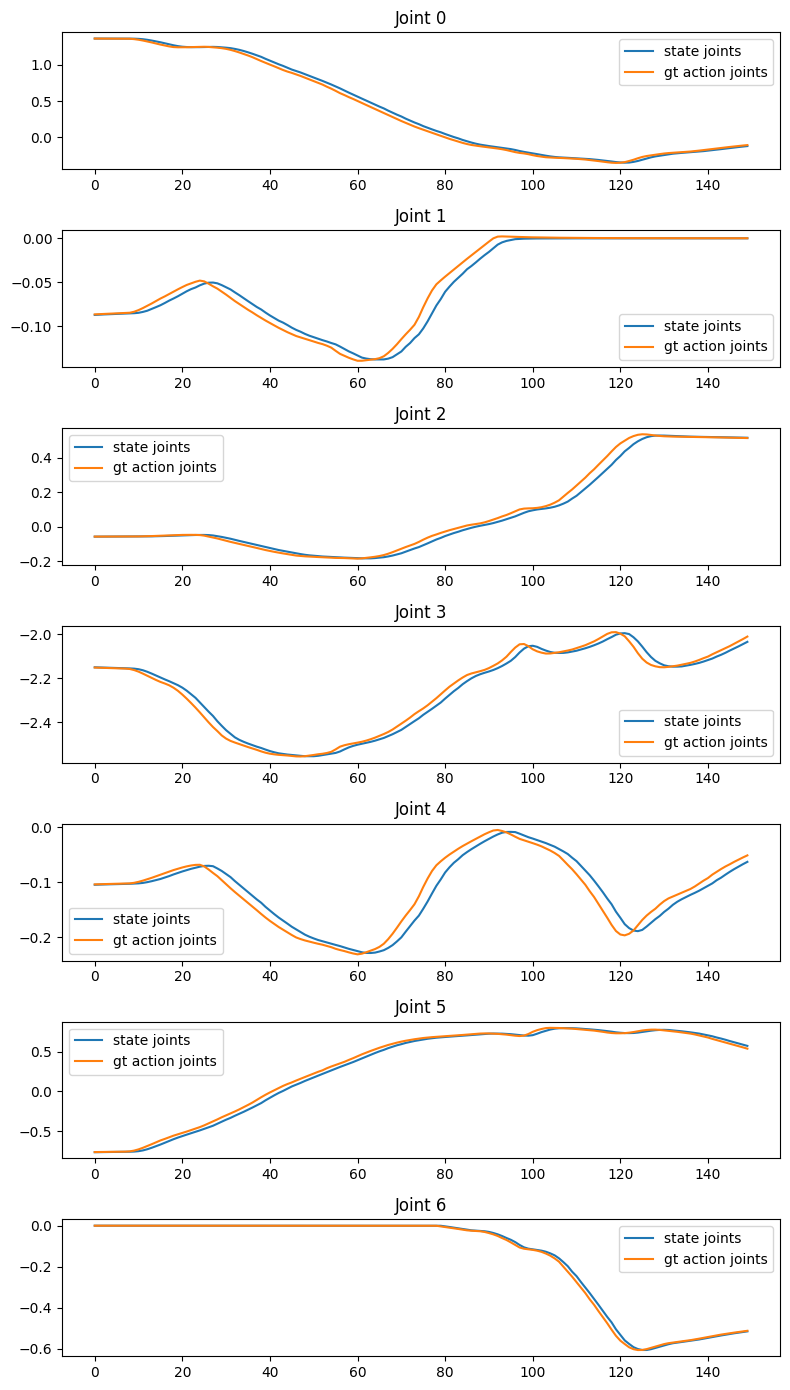

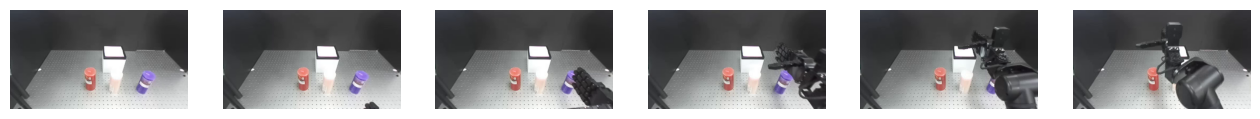

In [10]:
import matplotlib.pyplot as plt

traj_id = 0
max_steps = 150

state_joints_across_time = []
gt_action_joints_across_time = []
images = []

sample_images = 6

# Use keys from the loaded modality config instead of hardcoded keys
state_key = modality_config["state"].modality_keys[0]
action_key = modality_config["action"].modality_keys[0]
video_key = modality_config["video"].modality_keys[0]
print(f"Using keys -> state: {state_key}, action: {action_key}, video: {video_key}")

for step_count in range(max_steps):
    data_point = dataset.get_step_data(traj_id, step_count)
    state_joints = data_point[state_key][0]
    gt_action_joints = data_point[action_key][0]

    state_joints_across_time.append(state_joints)
    gt_action_joints_across_time.append(gt_action_joints)

    # We can also get the image data
    if step_count % max(1, (max_steps // sample_images)) == 0:
        image = data_point[video_key][0]
        images.append(image)

# Size is (max_steps, num_joints)
state_joints_across_time = np.array(state_joints_across_time)
gt_action_joints_across_time = np.array(gt_action_joints_across_time)


# Plot the joint angles across time
num_joints = state_joints_across_time.shape[1]
fig, axes = plt.subplots(nrows=num_joints, ncols=1, figsize=(8, 2 * num_joints))
if num_joints == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(state_joints_across_time[:, i], label="state joints")
    ax.plot(gt_action_joints_across_time[:, i], label="gt action joints")
    ax.set_title(f"Joint {i}")
    ax.legend()

plt.tight_layout()
plt.show()


# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))
if sample_images == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    if i < len(images):
        ax.imshow(images[i])
    ax.axis("off")

Now we can run the policy from the pretrained checkpoint.

In [11]:
step_data['video.cam_head'].shape
step_data['annotation.human.task_description']

['Pick up a red cylinder and place it on the basket.']

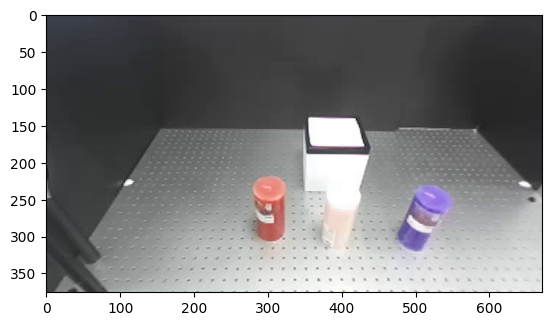

In [12]:
plt.imshow(step_data['video.cam_head'][0])

=== Baseline action shapes ===
action.right_arm (10, 7)
action.right_hand (10, 20)

=== Language sensitivity (same obs, different prompt) ===
action.right_arm
ta: torch.Size([70]), tb: torch.Size([70])
action.right_arm: cosine=0.999928, l1_mean=0.007961
action.right_hand
ta: torch.Size([200]), tb: torch.Size([200])
action.right_hand: cosine=0.999961, l1_mean=0.002347


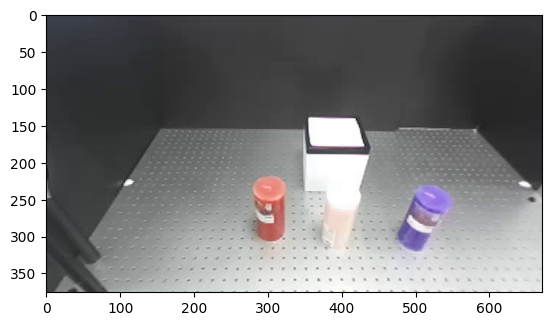

In [ ]:
import copy
import torch

predicted_action = policy.get_action(step_data)
print("=== Baseline action shapes ===")
for key, value in predicted_action.items():
    print(key, value.shape)

# Counterfactual language check: same observation, different prompt
lang_key = "annotation.human.task_description"
if lang_key not in step_data:
    print(f"[WARN] Language key '{lang_key}' not found. Available keys: {list(step_data.keys())}")
else:
    sample_a = copy.deepcopy(step_data)
    sample_b = copy.deepcopy(step_data)
    plt.imshow(sample_a['video.cam_head'][0])
    sample_a[lang_key] = ["Pick up a red cylinder and place it on the basket."]
    sample_b[lang_key] = ["pick the pear from the counter and place it in the plate."]

    pred_a = policy.get_action(sample_a)
    pred_b = policy.get_action(sample_b)
    print("\n=== Language sensitivity (same obs, different prompt) ===")
    for key in pred_a.keys():
        print(key)
        ta = torch.as_tensor(pred_a[key], dtype=torch.float32).flatten()
        tb = torch.as_tensor(pred_b[key], dtype=torch.float32).flatten()
        print(f"ta: {ta.shape}, tb: {tb.shape}")
        cos = torch.dot(ta, tb) / (torch.norm(ta) * torch.norm(tb) + 1e-8)
        l1 = torch.mean(torch.abs(ta - tb))
        print(f"{key}: cosine={cos.item():.6f}, l1_mean={l1.item():.6f}")

### Understanding the Action Output

For this checkpoint/config (`ffw_sh5_27dof`), each predicted action key has shape `(H, N)`.
- `H` is action horizon (10 for this config)
- `N` is DoF per action group

In this dataset:
- `action.right_arm`: 7 DoF
- `action.right_hand`: 20 DoF

### Language Sensitivity Check

The previous cell runs a counterfactual test:
- keeps the same observation
- changes only language prompt
- compares action outputs using cosine similarity and mean L1 distance

Interpretation:
- cosine ~ 1.0 and very small L1: weak language influence
- lower cosine / larger L1: stronger language conditioning